#  Normality Test 
<hr style="border:2.5px solid #aa269f"></hr>

<b>Desiree Valois</b>
<br>Computer Engineer

In [1]:
# imports and packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Shapiro-Wilk Test

In [2]:
# load dataset
df = pd.read_csv(r"dataset\defects-30-sample.csv",
                 delimiter=",",
                 index_col="Sample")
df

,Defects
Sample,
1,13
2,12
3,10
4,11
5,10
6,6
7,12
8,12
9,9


In [3]:
# summary of dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 1 to 30
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Defects  30 non-null     int64
dtypes: int64(1)
memory usage: 372.0 bytes


In [4]:
# summary of statistics
df.describe()

,Defects
count,30.000000
mean,11.033333
std,2.566137
min,5.000000
25%,9.250000
50%,11.500000
75%,13.000000
max,15.000000


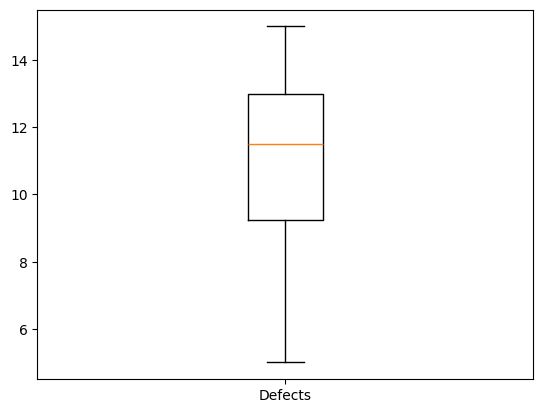

In [5]:
# check for outliers
plt.boxplot(df['Defects'],tick_labels=['Defects'])
plt.show()

In [6]:
# shapiro-wilk test
w_stat, p_value = stats.shapiro(df['Defects'])

print(f'w_stat: {w_stat:.4f}')
print(f'p_value: {p_value:.4f}')

w_stat: 0.9580
p_value: 0.2757


In [7]:
# verdict
alpha = 0.05

if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

Normal data


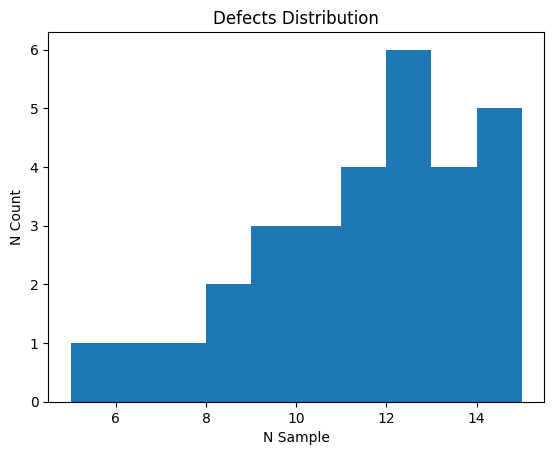

In [8]:
# defects distribution
plt.hist(df['Defects'])
plt.title('Defects Distribution')
plt.ylabel('N Count')
plt.xlabel('N Sample')
plt.show()

# Aderson-Darling Test

In [9]:
# load dataset
df = pd.read_csv(r"dataset\defects-count.csv",
                 delimiter=",",
                 index_col="Product")
df

,Defects
Product,
1,12
2,8
3,9
4,11
5,9
...,...
316,15
317,10
318,8


In [10]:
# summary of dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 1 to 320
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Defects  320 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [11]:
# summary of statistics
df.describe()

,Defects
count,320.000000
mean,10.325000
std,3.172274
min,1.000000
25%,8.000000
50%,11.000000
75%,12.000000
max,18.000000


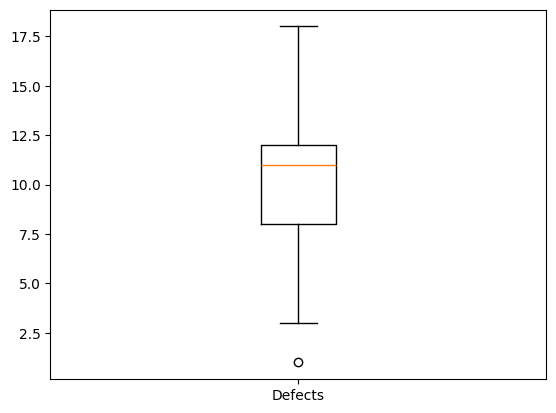

In [12]:
# check for outliers
plt.boxplot(df['Defects'],tick_labels=['Defects'])
plt.show()

In [13]:
# removing 3-sigma outliers
z = stats.zscore(df['Defects'])
outliers = (z<-3)|(z>3)
df = df[~outliers]

In [14]:
# anderson-darling statistics
a2_stat, critical, alpha = stats.anderson(df['Defects'])

print(f'a2_stat: {a2_stat:.4f}')
print(f'critical: {critical}')
print(f'alpha: {alpha}')

a2_stat: 1.6942
critical: [0.56  0.63  0.75  0.871 1.033]
alpha: [15.  10.   5.   2.5  1. ]


C:\Users\jdesi\AppData\Local\Temp\ipykernel_12360\2150977426.py:2: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  a2_stat, critical, alpha = stats.anderson(df['Defects'])


In [15]:
# verdict
# let alpha = 0.05
if a2_stat > critical[2]:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

Non-normal data


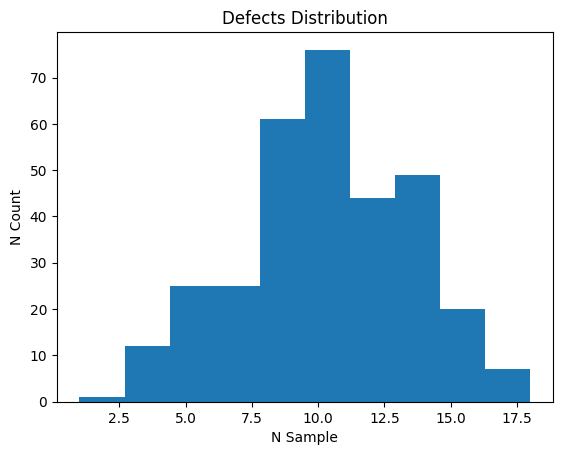

In [16]:
# defects distribution
plt.hist(df['Defects'])
plt.title('Defects Distribution')
plt.ylabel('N Count')
plt.xlabel('N Sample')
plt.show()